In [2]:
import os
import sys
from pathlib import Path

# Resolve paths from notebook location.
notebook_dir = Path.cwd()
project_root = Path(notebook_dir).parents[1]
src_path = project_root / "src"
style_path = project_root / "styles" / "pitayasmoothie-light.mplstyle"

print(str(src_path))
sys.path.insert(0, str(src_path))

# Force project plotting utilities to use local .mplstyle.
os.environ["EFF_PHYSICS_LEARN_MPLSTYLE"] = str(style_path)

import numpy as np

from solvers.ks import generate_ks_sample

from plotting import plot_solution_grid, plot_solution_rows, maybe_apply_style
import matplotlib.pyplot as plt

maybe_apply_style()
# Use viridis by default for image-like plots (e.g. Burgers solutions).
plt.rcParams["image.cmap"] = "inferno"


/home/etorres/Documents/Projects/git/eff-physics-learn-dataset/src


In [3]:
# u, x, t, ok, metrics = generate_burgers_sample(
#     nu=0.1,
#     A=1.0,
#     k=1.0,
#     solver_nx=256,
#     solver_nt=256,
#     target_nx=64,
#     target_nt=64,
#     )

solutions = [
    generate_ks_sample(
        alpha=alpha,
        beta=beta,
        gamma=gamma,
        x_domain=(0.0, 32.0 * np.pi),
        t_domain=(0.0, 150.0),
        solver_nx=256,
        solver_nt=601,
        target_nx=64,
        target_nt=64,
        verify=True,
    )
    for alpha, beta, gamma in [
        (1.10, 1.20, 1.20),
        (0.95, 1.00, 1.10),
        (1.05, 0.90, 1.25),
    ]
]

print(solutions[0][0].shape)
print(len(solutions[:]))

(64, 64)
3


valid: True metrics: {'pde_loss': 0.9499981665661175, 'bc_loss': 0.0, 'ic_loss': 8.214082984351105e-32, 'pde_ok': True, 'bc_ok': True, 'ic_ok': True}


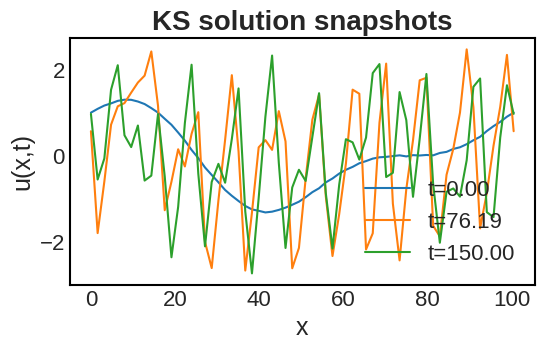

In [4]:
# Plot snapshots from the first KS solution.

u0, x, t, ok, metrics = solutions[0]
print("valid:", ok, "metrics:", metrics)

fig, ax = plt.subplots(figsize=(6, 3.2))
ax.plot(x, u0[0], label=f"t={t[0]:.2f}")
ax.plot(x, u0[len(u0)//2], label=f"t={t[len(u0)//2]:.2f}")
ax.plot(x, u0[-1], label=f"t={t[-1]:.2f}")
ax.set_xlabel("x")
ax.set_ylabel("u(x,t)")
ax.set_title("KS solution snapshots")
ax.legend()
plt.show()

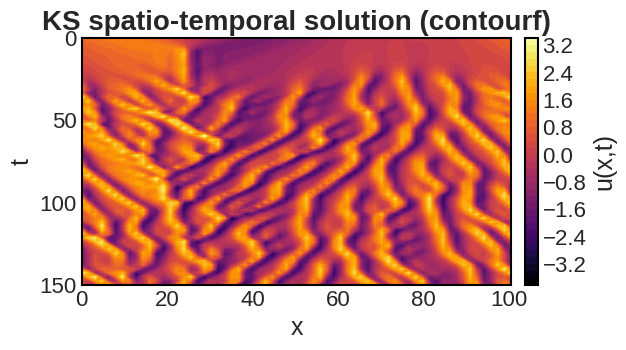

In [6]:
fig, ax = plt.subplots(figsize=(6, 3.2))

# u0 has shape (T, X): rows = time, cols = x
cf = ax.contourf(
    x,          # x-axis coordinates
    t,          # t-axis coordinates
    u0,         # (T, X)
    levels=40,
    cmap=plt.get_cmap(),
)

fig.colorbar(cf, ax=ax, fraction=0.046, pad=0.03, label="u(x,t)")
ax.set_xlabel("x")
ax.set_ylabel("t")
ax.set_title("KS spatio-temporal solution (contourf)")

# Match Burgers orientation: t=0 at top, t_max at bottom
ax.set_ylim(t.max(), t.min())

plt.show()

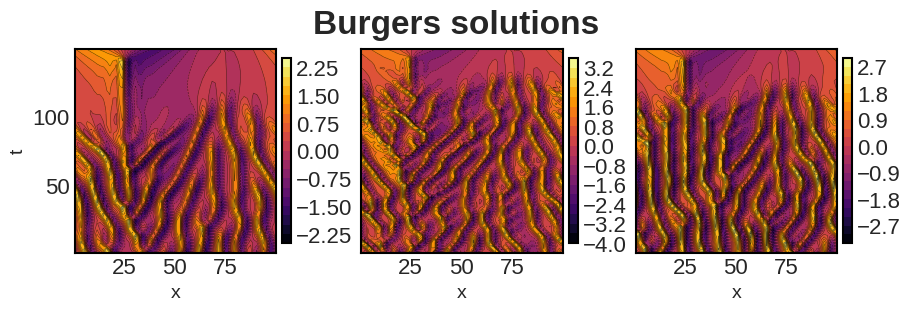

In [18]:
# Use three distinct time slices from the Burgers solution.
# u has shape (T, X): treat t as vertical axis, x as horizontal.
T = solutions[0][0].shape[0]
x = solutions[0][1]
t = solutions[0][2]
num_cols = 3
slice_indices = np.linspace(0, T - 1, num_cols, dtype=int)
sol = [u for u, _, _, _, _ in solutions]  # (num_cols, X) – plot_solution_rows will treat as (N, H, W)

# Plot using contourf with overlaid contours, showing x and t axes.
fig = plot_solution_rows(
    solutions_by_split={"burgers": sol},
    n_per_row=num_cols,
    plot_style="contourf",
    contour_levels=20,
    contour_line_color="black",
    extent=(x.min(), x.max(), t.max(), t.min()),
    show_axes=True,
    title="Burgers solutions",
)
plt.show()